# ChaosQKT with Psyduck: Quantum Chaos Simulation Tutorial

**Tutorial for Quantum Chaos Simulations using the Psyduck Framework**

This notebook demonstrates quantum chaos dynamics simulations using the **psyduck** library combined with custom helper functions from **ChaosQKT_pd_functions**.

The notebook uses ONLY:
- `psyduck` module (core framework)
- `psyduck.plotting` subfolder (Wigner visualization)
- `ChaosQKT_pd_functions` (custom chaos simulation functions)

NO functions from the `ChaosQKT` package (fitting, math_operations, plotting, utilities) are used.

## Section 1: Setup and Imports

Import psyduck and custom helper functions.

In [1]:
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import importlib

# Add the project root to Python path (2 levels up from examples/chaosqkt/)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, project_root)

# Force reload of psyduck modules
for module_name in list(sys.modules.keys()):
    if module_name.startswith('psyduck'):
        del sys.modules[module_name]

# Import psyduck library fresh
from psyduck import Spin
from psyduck.plotting import *
from psyduck.evolve import kicked_dynamics
from psyduck.operations import global_rotation
from psyduck.hamiltonians import Hz_order

# Import custom ChaosQKT helper functions
import ChaosQKT_functions as qkt

print("✓ Psyduck loaded successfully!")
print("✓ ChaosQKT_functions loaded successfully!")
print(f"QuTiP version: {qt.__version__}")

✓ Psyduck loaded successfully!
✓ ChaosQKT_functions loaded successfully!
QuTiP version: 5.2.3


## Section 2: Initialize Spin System

Create a Spin object using psyduck.

In [2]:
# Define spin quantum number
I = 7/2  # Spin-7/2 system (dimension 8)

# Create a Spin object using psyduck
nucleus = Spin(I=I)

print(f"✓ Created Spin system: I = {I}")
print(f"  Hilbert space dimension: {nucleus.dim}")

# Get spin operators from psyduck
Ix, Iy, Iz = nucleus.get_spin_operators()
print(f"✓ Spin operators created (shape: {Ix.shape})")

✓ Created Spin system: I = 3.5
  Hilbert space dimension: 8
✓ Spin operators created (shape: (8, 8))


## Section 3: Create Initial Spin-Coherent State

In [35]:
# Create a spin-coherent state at specific polar angles
theta = 0.0 * np.pi  # Polar angle (0 to π)
phi = 0.0 * np.pi   # Azimuthal angle (0 to 2π)

# Use the spin.py method to create the displaced coherent state
nucleus.make_displaced_coherent_state(theta=theta, phi=phi)
psi_initial = nucleus.state

print(f"✓ Created initial state at θ={theta:.3f}, φ={phi:.3f}")



✓ Created initial state at θ=0.000, φ=0.000


### 3.1 Visualize Prepared State in Hammer Projection

Plot the Wigner function of the prepared spin-coherent state using Hammer projection.

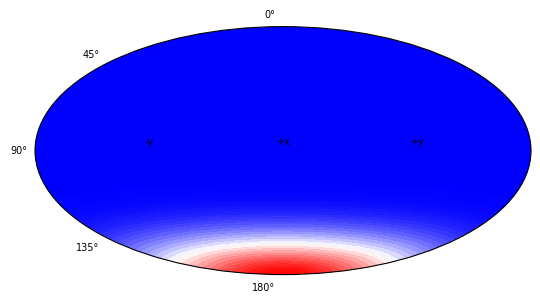

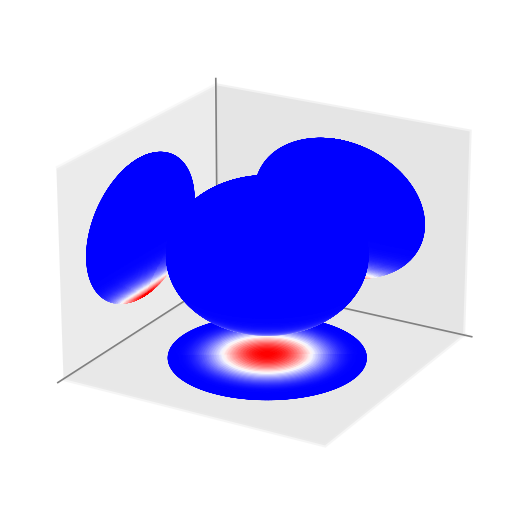

✓ Initial state visualized in Hammer projection
  The sharp peak indicates a well-defined spin-coherent state


In [46]:
# Visualize the prepared state using psyduck's wigner_plot_hammer
fig, ax, _ = wigner_plot_hammer(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)
plt.show()



# Visualize the prepared state using psyduck's projection_plot_spin_wigner
fig, ax, _, _, _ = projection_plot_spin_wigner(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr',
    figsize=(2, 2)
)
plt.show()  



print("✓ Initial state visualized in Hammer projection")
print(f"  The sharp peak indicates a well-defined spin-coherent state")


### 3.2 Time Evolution and Expectation Values

Calculate expectation values using the `Spin.expectation()` method from psyduck.

In [5]:
# Get spin operators
Ix, Iy, Iz = nucleus.get_spin_operators()

# Calculate expectation values using Spin.expectation() method
exp_Ix = nucleus.expectation(Ix)
exp_Iy = nucleus.expectation(Iy)
exp_Iz = nucleus.expectation(Iz)

print(f"\nExpectation values using nucleus.expectation():")
print(f"  <Jx> = {exp_Ix:.4f}")
print(f"  <Jy> = {exp_Iy:.4f}")
print(f"  <Jz> = {exp_Iz:.4f}")

# Calculate linear entropy using nucleus.linear_entropy() method
entropy = nucleus.linear_entropy()
print(f"\nLinear entropy (using nucleus.linear_entropy):\n {entropy:.6f}")


Expectation values using nucleus.expectation():
  <Jx> = 0.0000
  <Jy> = 0.0000
  <Jz> = 3.5000

Linear entropy (using nucleus.linear_entropy):
 0.000000


## Section 4: Run Kicked Dynamics Simulation

Simulate the quantum kicked top with nonlinear pulses, then visualize the evolution with an interactive slider showing Wigner functions in Hammer projection after each kick. The Hamiltonian of the kicked top has the form,
$$
H(t) = \frac{\pi}{2\tau} I_y + \frac{\kappa}{2j} I_z^2
$$
equation (2) from
Neill, C. et al. "Ergodic dynamics and thermalization in an isolated quantum system." Nature Phys 12, 1037–1041 (2016).


Note here, in `kicked_dynamics(psi_initial, tau, kappa, I, N, order, pulse_type)`, the `order` argument sets the power of the nonlinear kick operator, `U_pulse = exp[-i * kappa * I_z**order / (order * I**(order - 1))]`.
The `order` parameter controls the nonlinearity:
- **Order 2** (quadratic): $I_z^2$ -> weaker, smoother
- **Order 3** (cubic): $I_z^3$ -> stronger, more chaotic
- **Higher orders**: More complex classical dynamics


In [6]:
# Simulation parameters
tau = 1.0      # Free evolution time between kicks
kappa = 3.5 * np.pi    # Kick strength (nonlinearity parameter)
N_kicks = 20   # Number of kicks
order = 2      # Nonlinear kick order

print("Running kicked dynamics simulation...")
print(f"Parameters: tau={tau}, kappa={kappa}, N={N_kicks}, order={order}")

# Use kicked_dynamics from psyduck.evolve
psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
    psi_initial, tau, kappa, I, N=N_kicks, order=order, pulse_type='pulse'
)

print(f"✓ Simulation completed!")
print(f"  Generated {len(psi_list)} states")
print(f"\nChaos Metrics:")
print(f"  Initial entropy: {entropy_list[0]:.6f}")
print(f"  Final entropy: {entropy_list[-1]:.6f}")
print(f"  Entropy increase: {entropy_list[-1] - entropy_list[0]:.6f}")
print(f"  Final overlap: |<ψ(0)|ψ(T)>| = {abs(overlap_list[-1]):.6f}")

Running kicked dynamics simulation...
Parameters: tau=1.0, kappa=10.995574287564276, N=20, order=2
✓ Simulation completed!
  Generated 21 states

Chaos Metrics:
  Initial entropy: 0.000000
  Final entropy: 0.000000
  Entropy increase: 0.000000
  Final overlap: |<ψ(0)|ψ(T)>| = 0.125000


### 4.1 Interactive Wigner Function Visualization with Slider

Use the slider below to explore the Wigner function after each kick. The Hammer projection shows the phase space evolution throughout the simulation.

In [7]:
from psyduck.plotting.wigner_plot import plot_wigner_evolution_frame
from ipywidgets import interact, IntSlider, fixed
%matplotlib inline
# Create interactive slider widget
print("\n" + "="*70)
print("Interactive Wigner Function Visualization")
print("="*70)
print(f"Slide to browse through all {len(psi_list)} states")
print(f"Observe phase space evolution from kick 0 to {N_kicks}")
print("="*70 + "\n")

interact(
    plot_wigner_evolution_frame,
    kick_number=IntSlider(
        min=0,
        max=N_kicks,
        step=1,
        value=0,
        description="Kick:",
        continuous_update=True,
        layout={"width": "500px"}
    ),
    psi_list=fixed(psi_list),
    entropy_list=fixed(entropy_list),
    overlap_list=fixed(overlap_list)
)



Interactive Wigner Function Visualization
Slide to browse through all 21 states
Observe phase space evolution from kick 0 to 20



interactive(children=(IntSlider(value=0, description='Kick:', layout=Layout(width='500px'), max=20), IntSlider…

<function psyduck.plotting.wigner_plot.plot_wigner_evolution_frame(kick_number, psi_list, entropy_list, overlap_list, n_theta=101, n_phi=201, cmap='bwr')>

### Section 4.2: Plot Evolution Metrics

Visualize the system dynamics across all kicks from the Section 4 simulation.

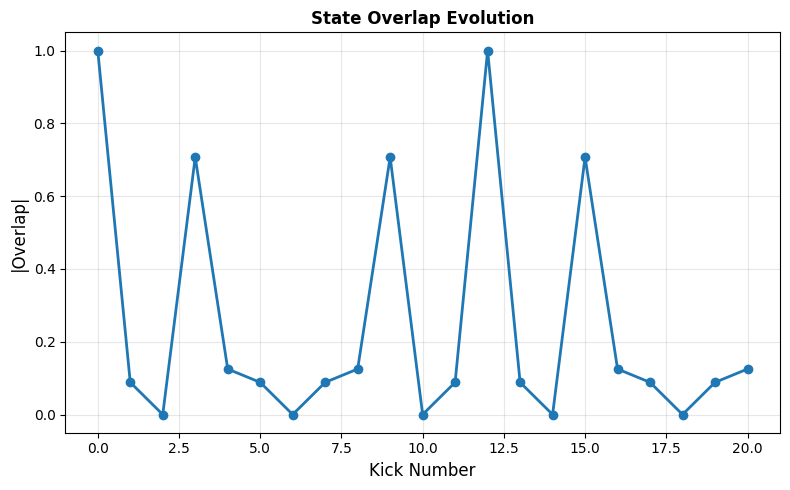

In [8]:
# Plot 1: Overlap evolution
fig_overlap, ax_overlap = plt.subplots(figsize=(8, 5))
ax_overlap.plot(range(len(overlap_list)), abs(np.array(overlap_list)), 'o-', 
                linewidth=2, markersize=6, color='C0')
ax_overlap.set_xlabel('Kick Number', fontsize=12)
ax_overlap.set_ylabel('|Overlap|', fontsize=12)
ax_overlap.set_title('State Overlap Evolution', fontsize=12, fontweight='bold')
ax_overlap.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

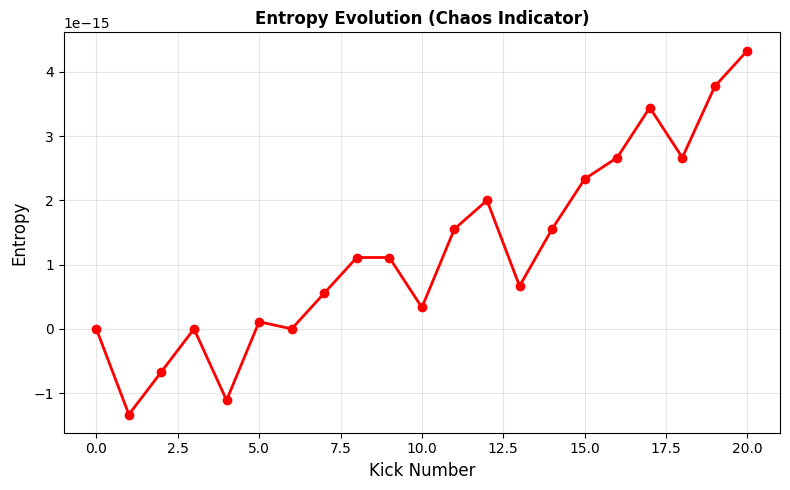

In [9]:
# Plot 2: Entropy evolution
fig_entropy, ax_entropy = plt.subplots(figsize=(8, 5))
ax_entropy.plot(range(len(entropy_list)), entropy_list, 'o-', 
                color='red', linewidth=2, markersize=6)
ax_entropy.set_xlabel('Kick Number', fontsize=12)
ax_entropy.set_ylabel('Entropy', fontsize=12)
ax_entropy.set_title('Entropy Evolution (Chaos Indicator)', fontsize=12, fontweight='bold')
ax_entropy.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

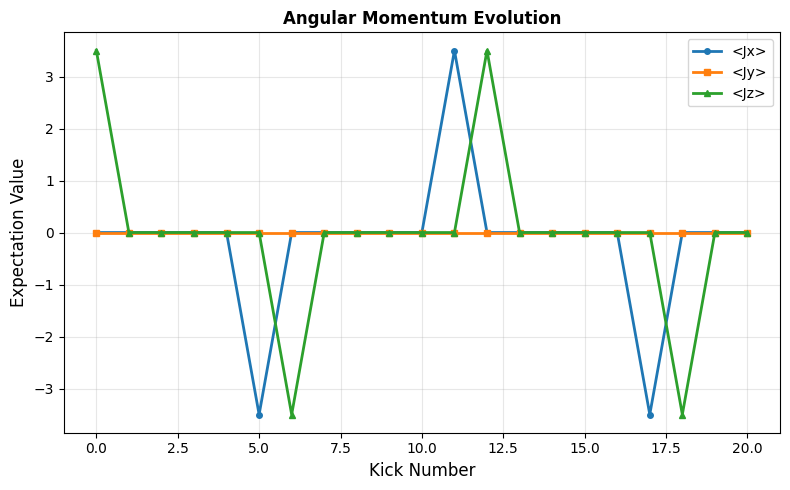

In [10]:
# Plot 3: Expectation values evolution
exp_array = np.array(exp_list)
kicks = np.arange(len(exp_list))
fig_exp, ax_exp = plt.subplots(figsize=(8, 5))
ax_exp.plot(kicks, exp_array[:, 0], 'o-', label='<Jx>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 1], 's-', label='<Jy>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 2], '^-', label='<Jz>', linewidth=2, markersize=4)
ax_exp.set_xlabel('Kick Number', fontsize=12)
ax_exp.set_ylabel('Expectation Value', fontsize=12)
ax_exp.set_title('Angular Momentum Evolution', fontsize=12, fontweight='bold')
ax_exp.legend(fontsize=10)
ax_exp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Compare Kicked Dynamics Across Different Spin Numbers

Run kicked dynamics with tunable spin number I (while keeping all other parameters fixed from Section 4), then compare the state overlap evolution across different spin systems.


In [11]:
# Section 5: Setup parameters (tunable spin number, fixed other parameters)
# Use the same parameters from Section 4, but allow varying spin number I

# ===== TUNABLE PARAMETERS =====
spin_numbers = [3.5]  # Change (add) this list to compare different spin systems
# ==============================

# Fixed parameters (from Section 4)
tau = 1.0      # Free evolution time between kicks
kappa = 3.5 * np.pi    # Kick strength (nonlinearity parameter)
N_kicks = 20   # Number of kicks
order = 2      # Nonlinear kick order

print("="*70)
print("Section 5: Comparing Overlap Evolution Across Spin Numbers")
print("="*70)
print(f"Fixed parameters: τ={tau}, κ={kappa}, N={N_kicks}, order={order}")
print(f"Varying spin numbers: {spin_numbers}")

# Dictionary to store results for each spin number
overlap_data = {}
entropy_data = {}

# Run kicked dynamics for each spin number
for spin_I in spin_numbers:
    # Create a Spin object
    nucleus_compare = Spin(I=spin_I)
    nucleus_compare.make_displaced_coherent_state(theta=0, phi=0)
    psi_initial_compare = nucleus_compare.state
    
    # Run kicked dynamics
    psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
        psi_initial_compare, tau, kappa, spin_I, N=N_kicks, order=order, pulse_type='pulse'
    )
    
    # Store results
    overlap_data[spin_I] = overlap_list
    entropy_data[spin_I] = entropy_list
 


Section 5: Comparing Overlap Evolution Across Spin Numbers
Fixed parameters: τ=1.0, κ=10.995574287564276, N=20, order=2
Varying spin numbers: [3.5]


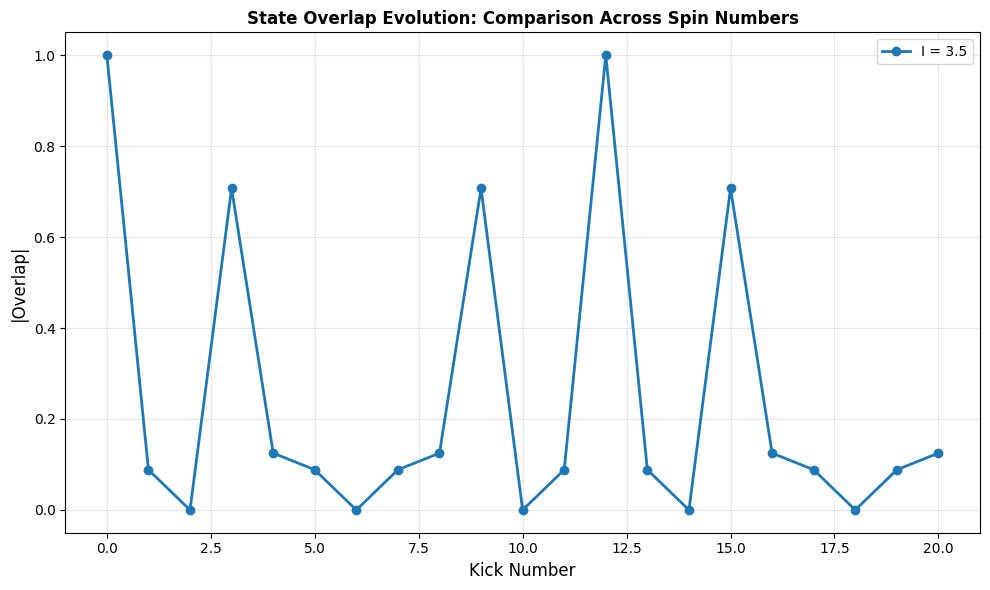

In [12]:
# Section 5: Plot overlap evolution comparison across spin numbers

fig_overlap_compare, ax_overlap_compare = plt.subplots(figsize=(10, 6))

for spin_I in spin_numbers:
    ax_overlap_compare.plot(
        range(len(overlap_data[spin_I])), 
        abs(np.array(overlap_data[spin_I])), 
        'o-', linewidth=2, markersize=6, label=f'I = {spin_I}'
    )

ax_overlap_compare.set_xlabel('Kick Number', fontsize=12)
ax_overlap_compare.set_ylabel('|Overlap|', fontsize=12)
ax_overlap_compare.set_title('State Overlap Evolution: Comparison Across Spin Numbers', 
                              fontsize=12, fontweight='bold')
ax_overlap_compare.legend(fontsize=10)
ax_overlap_compare.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 6: Compare Initial and Final States

Visualize the phase space evolution using different Wigner function projections from psyduck.plotting.

### Section 6.1: Hammer Projection

Visualize the phase space using Hammer projection from psyduck.plotting.

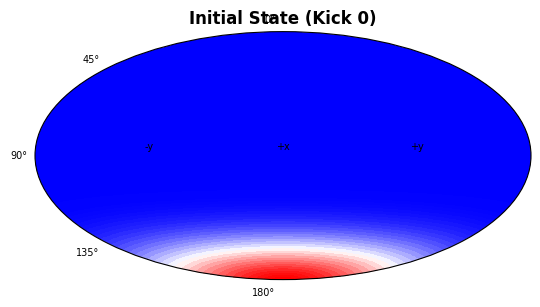

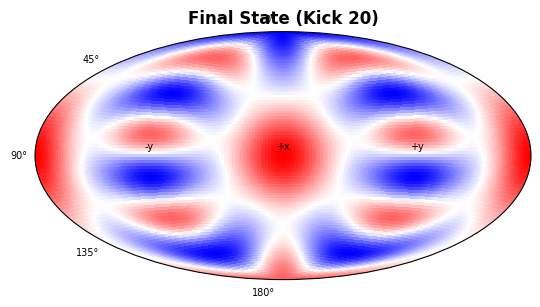

✓ Initial and final states compared
  Initial: Sharp peak indicating pure spin-coherent state
  Final: Spread distribution indicating decoherence/chaos


In [13]:
# Compare initial and final states using wigner_plot_hammer
# Initial state
fig_init, ax_init, _ = wigner_plot_hammer(psi_list[0], n_theta=101, n_phi=201, cmap='bwr')
ax_init.set_title('Initial State (Kick 0)', fontsize=12, fontweight='bold')
plt.show()

# Final state
fig_final, ax_final, _ = wigner_plot_hammer(psi_list[-1], n_theta=101, n_phi=201, cmap='bwr')
ax_final.set_title(f'Final State (Kick {len(psi_list)-1})', fontsize=12, fontweight='bold')
plt.show()

print("✓ Initial and final states compared")
print(f"  Initial: Sharp peak indicating pure spin-coherent state")
print(f"  Final: Spread distribution indicating decoherence/chaos")

## Section 7: Dynamical Tunneling Analysis

Analyze tunneling dynamics by computing overlap (fidelity) with the initial state and identifying tunneling frequencies via FFT.

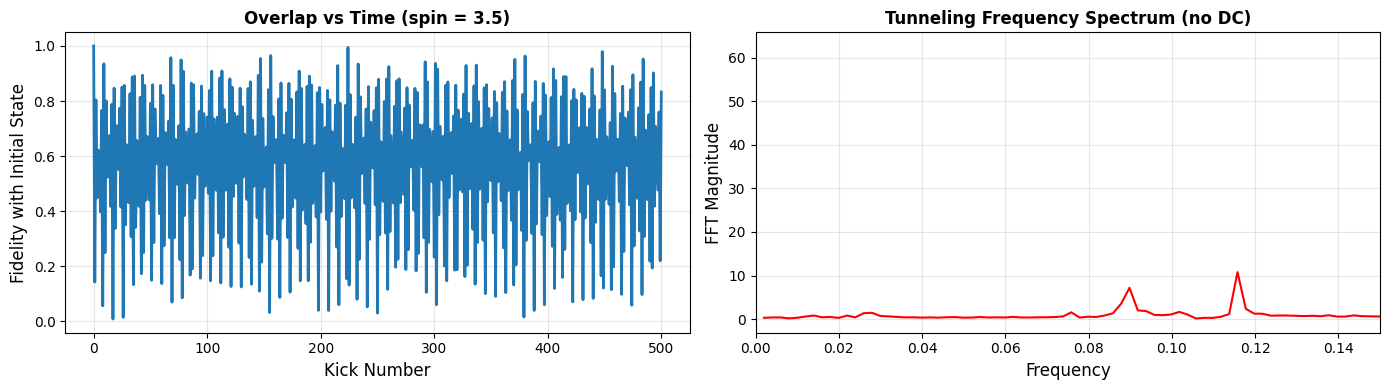

✓ Tunneling analysis completed for spin = 3.5
  Initial fidelity: 1.000000
  Final fidelity: 0.833023
  Fidelity evolution range: [0.008050, 1.000000]


In [14]:
# Single spin system tunneling analysis
spin = 3.5

# Create a new Spin object for tunneling analysis
tunnel_nucleus = Spin(I=spin)
tunnel_nucleus.make_displaced_coherent_state(theta=2.25, phi=0.7)
psi_tunnel_initial = tunnel_nucleus.state

# Run kicked dynamics for tunneling analysis
tau = 1.0
kappa = 3.0
n_kicks = 500

psi_tunnel_list, _, _, _ = kicked_dynamics(
    psi_tunnel_initial, tau, kappa, spin, N=n_kicks, order=2, pulse_type='pulse'
)

# Calculate overlap (fidelity) with initial state
overlap = np.zeros(len(psi_tunnel_list))
for i in range(len(psi_tunnel_list)):
    overlap[i] = qt.fidelity(psi_tunnel_list[0], psi_tunnel_list[i])

# Compute FFT
fft_vals = np.fft.fft(overlap)
fft_freqs = np.fft.fftfreq(len(overlap))

# Remove DC component
fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
fft_mag = np.abs(fft_vals_no_dc)

# Plot overlap and FFT
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Fidelity over time
axes[0].plot(np.arange(len(overlap)), overlap, linewidth=2, color='C0')
axes[0].set_xlabel('Kick Number', fontsize=12)
axes[0].set_ylabel('Fidelity with Initial State', fontsize=12)
axes[0].set_title(f'Overlap vs Time (spin = {spin})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: FFT magnitude spectrum
axes[1].plot(fft_freqs_no_dc, fft_mag, linewidth=1.5, color='red')
axes[1].set_xlim(0, 0.15)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_ylabel('FFT Magnitude', fontsize=12)
axes[1].set_title('Tunneling Frequency Spectrum (no DC)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Tunneling analysis completed for spin = {spin}")
print(f"  Initial fidelity: {overlap[0]:.6f}")
print(f"  Final fidelity: {overlap[-1]:.6f}")
print(f"  Fidelity evolution range: [{np.min(overlap):.6f}, {np.max(overlap):.6f}]")

### 7.1 Compare Multiple Spins

Study how tunneling behavior depends on the spin quantum number.

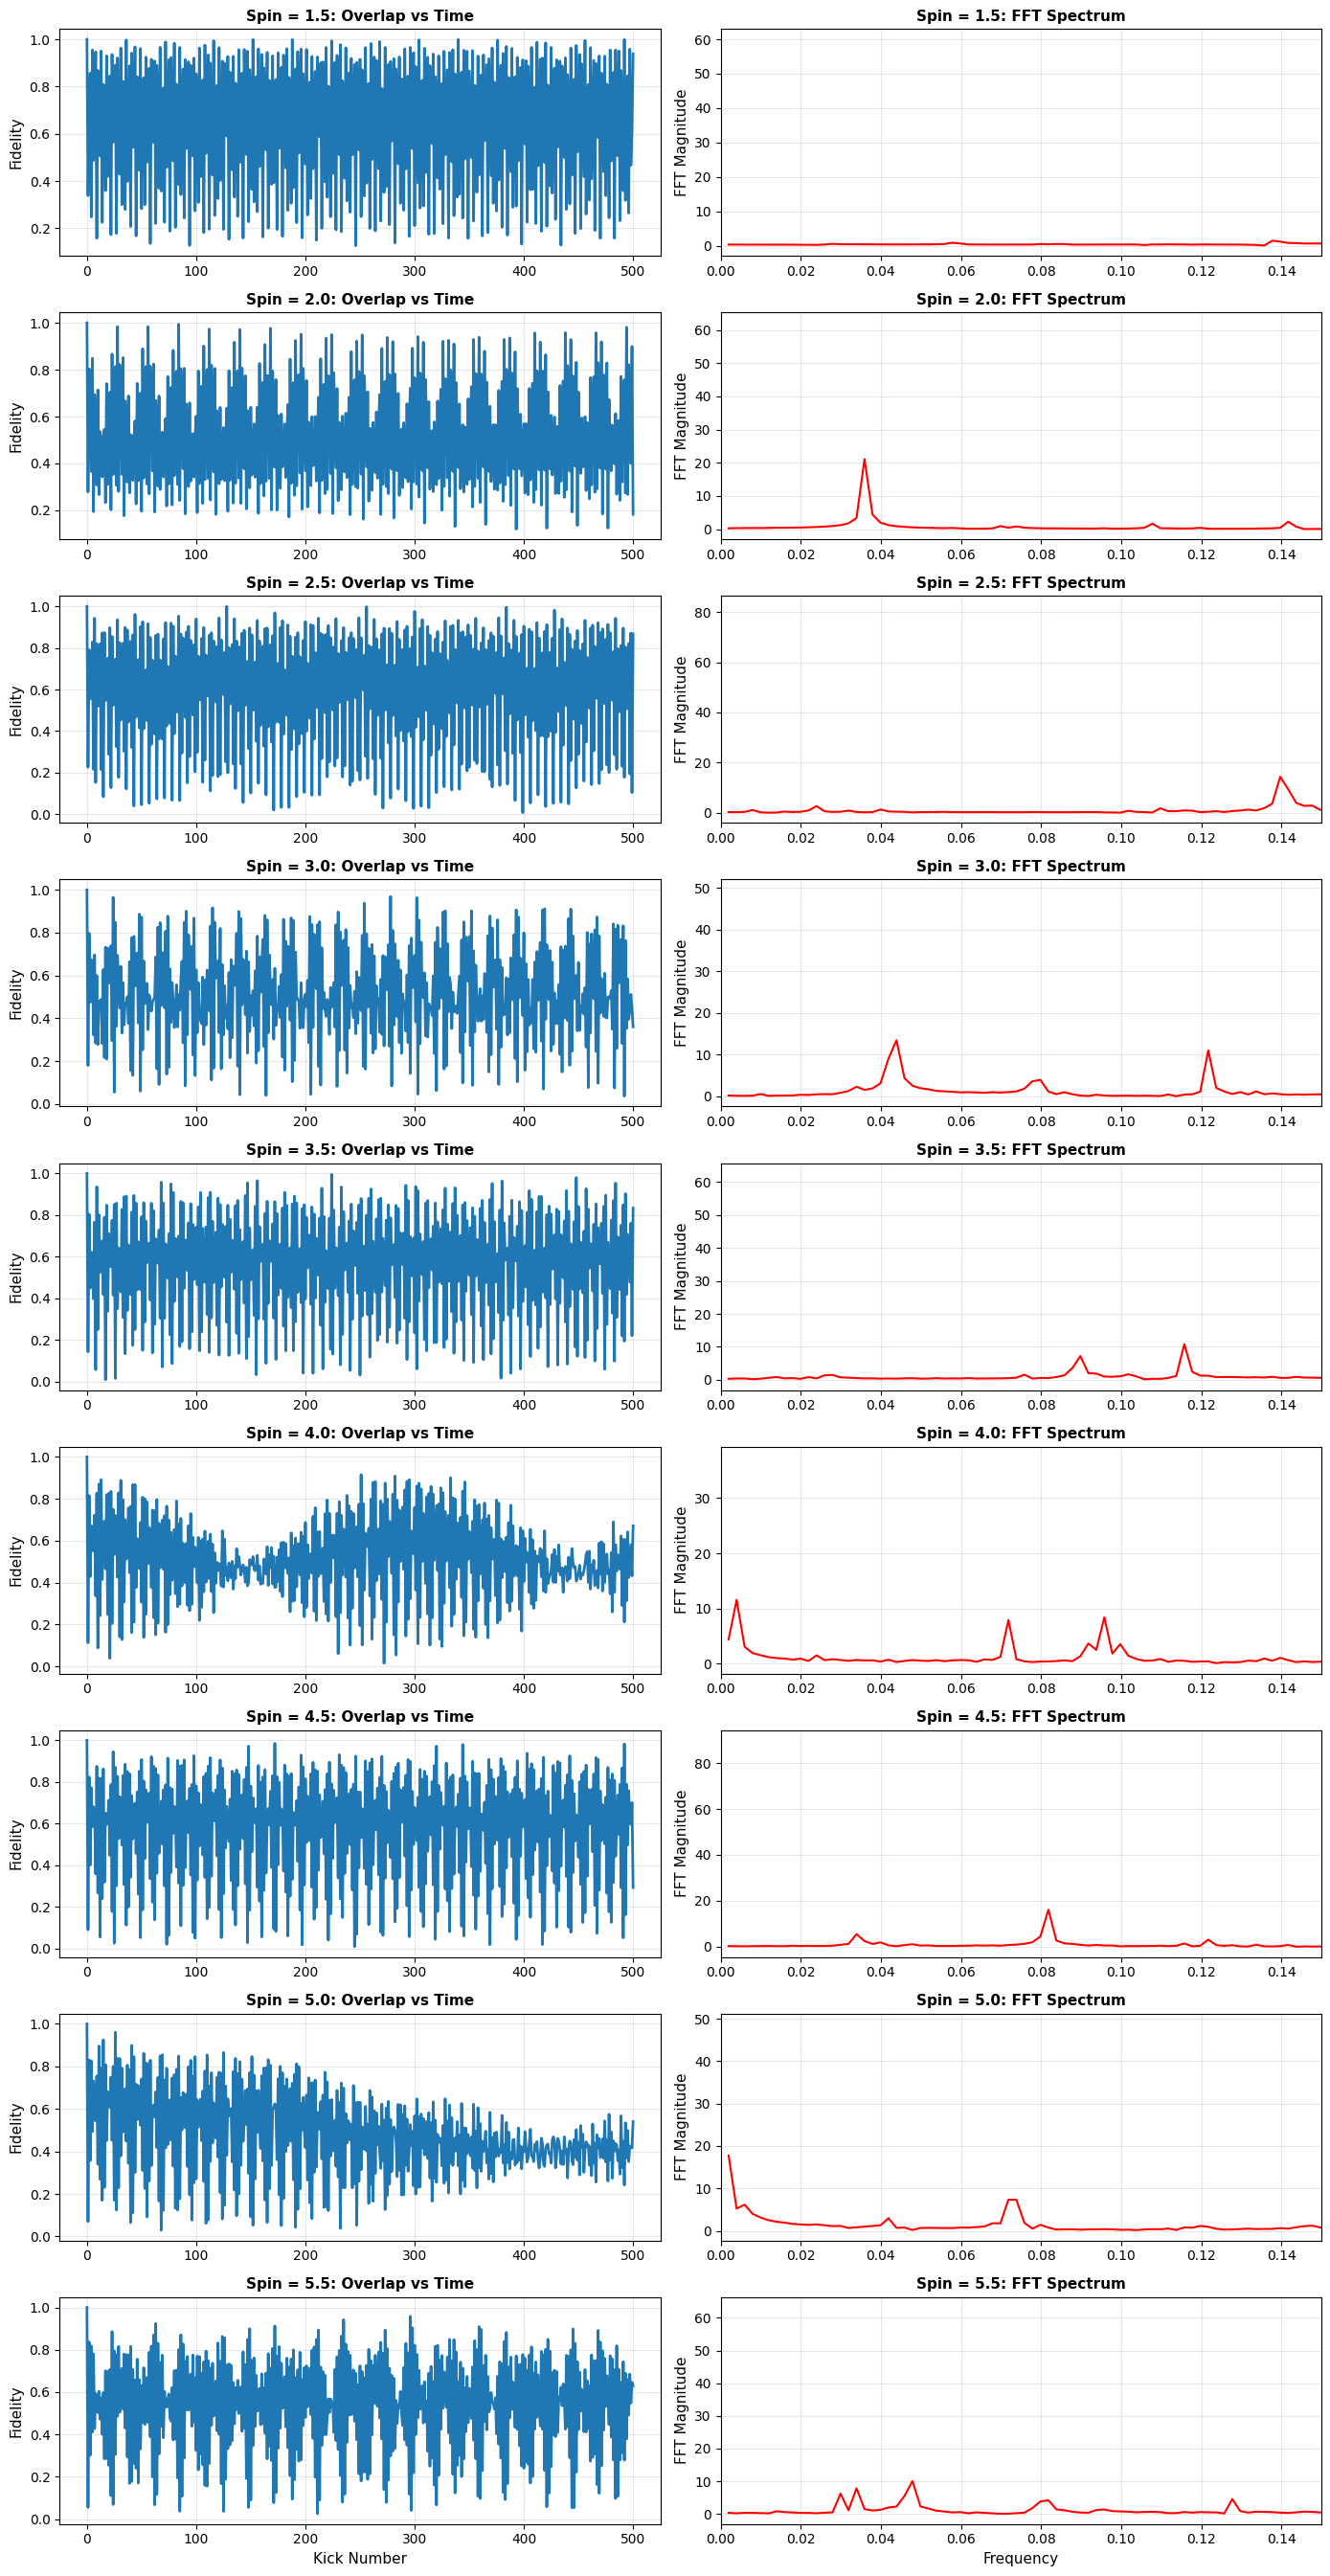

✓ Multi-spin tunneling analysis completed for 9 systems
  Spin values: [1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]
  Parameters: τ=1.0, κ=3.0, N=500
  Fidelity ranges by spin:
    I = 1.5: [0.1265, 1.0000]
    I = 2.0: [0.1197, 1.0000]
    I = 2.5: [0.0074, 1.0000]
    I = 3.0: [0.0362, 1.0000]
    I = 3.5: [0.0080, 1.0000]
    I = 4.0: [0.0151, 1.0000]
    I = 4.5: [0.0079, 1.0000]
    I = 5.0: [0.0294, 1.0000]
    I = 5.5: [0.0260, 1.0000]


In [15]:
# Multi-spin tunneling analysis
spin_values = np.arange(1.5, 6, 0.5)
n_spins = len(spin_values)

# Storage for results
overlaps = {}
fft_data = {}

# Common parameters
tau = 1.0
kappa = 3.0
n_kicks = 500

# Run analysis for each spin value
for spin in spin_values:
    # Create Spin object
    tunnel_nucleus = Spin(I=spin)
    tunnel_nucleus.make_displaced_coherent_state(theta=2.25, phi=0.7)
    psi_initial = tunnel_nucleus.state
    
    # Run kicked dynamics
    psi_list, _, _, _ = kicked_dynamics(
        psi_initial, tau, kappa, spin, N=n_kicks, order=2, pulse_type='pulse'
    )
    
    # Calculate overlap
    overlap = np.zeros(len(psi_list))
    for i in range(len(psi_list)):
        overlap[i] = qt.fidelity(psi_list[0], psi_list[i])
    
    overlaps[spin] = overlap
    
    # Compute FFT
    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    
    # Remove DC component
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
    fft_mag = np.abs(fft_vals_no_dc)
    
    fft_data[spin] = (fft_freqs_no_dc, fft_mag)

# Create subplot grid
fig, axes = plt.subplots(n_spins, 2, figsize=(14, 3*n_spins))

# Plot results for each spin
for idx, spin in enumerate(spin_values):
    # Left: Overlap vs time
    axes[idx, 0].plot(np.arange(len(overlaps[spin])), overlaps[spin], linewidth=2, color='C0')
    axes[idx, 0].set_ylabel('Fidelity', fontsize=11)
    axes[idx, 0].set_title(f'Spin = {spin}: Overlap vs Time', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Right: FFT spectrum
    fft_freqs, fft_mag = fft_data[spin]
    axes[idx, 1].plot(fft_freqs, fft_mag, linewidth=1.5, color='red')
    axes[idx, 1].set_xlim(0, 0.15)
    axes[idx, 1].set_ylabel('FFT Magnitude', fontsize=11)
    axes[idx, 1].set_title(f'Spin = {spin}: FFT Spectrum', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

# Set x-labels only on bottom row
for col in range(2):
    axes[-1, col].set_xlabel('Kick Number' if col == 0 else 'Frequency', fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ Multi-spin tunneling analysis completed for {n_spins} systems")
print(f"  Spin values: {spin_values}")
print(f"  Parameters: τ={tau}, κ={kappa}, N={n_kicks}")
print(f"  Fidelity ranges by spin:")
for spin in spin_values:
    overlap = overlaps[spin]
    print(f"    I = {spin}: [{np.min(overlap):.4f}, {np.max(overlap):.4f}]")

# Section 8: Trotterized vs Continuous Kicked-Top Evolution

This section uses the `psyduck` workflow together with helper functions from `ChaosQKT_functions.py`:
- create the system with `nucleus = Spin(I=3.5)`
- build the higher-order kick with `hamiltonians.Hz_order(...)`
- construct and execute the Trotter step with helpers from `ChaosQKT_functions.py`
- compare the Trotterized dynamics against `Spin.evolve()` under the full Hamiltonian

We will:
1. set up the Trotterization parameters and construct the single-step operators
2. execute the Trotterized evolution
3. compare the final Trotterized and continuous states with side-by-side Wigner plots
4. compare the population trajectories of the Trotterized and continuous evolutions
5. repeat the comparison for several `delta_tau` values to show convergence


In [16]:
# Section 8.1: Setup Trotterization Parameters and Construct the Trotter Operators

I = 3.5
theta0 = np.pi / 2
phi0 = 0.0

nucleus = Spin(I=I)
nucleus.make_displaced_coherent_state(theta=theta0, phi=phi0)
psi0 = nucleus.state.copy()

Ix, Iy, Iz = nucleus.get_spin_operators()
d = nucleus.dim


# Create the unitary operators for performing the trotterized step evolutions
order = 2
kappa = 3.5 * np.pi # Iz kick strength.
omega_y = np.pi / 2 # Y-drive strength in the Hamiltonian Hy = -omega_drive * Iy.
T_total = 2.0
n_trotter = 6
delta_tau = T_total / n_trotter #Trotter time step.

Hz = Hz_order(kappa, order, I)  # Higher-order Z Hamiltonian term.
Hy = -omega_y * Iy
H_total = Hy + Hz

Uy_step = global_rotation(I, -omega_y * delta_tau, 'y')
Uz_step = (-1j * delta_tau * Hz).expm()
U_step = Uz_step * Uy_step


print("=== Section 8.1 ===")
print(f"Spin system: Spin(I={I}) with dimension {d}")
print(f"Initial coherent state: theta = {theta0:.3f}, phi = {phi0:.3f}")
print(f"order = {order}")
print(f"kappa = {kappa:.6f}")
print(f"omega_y = {omega_y:.6f}")
print(f"T_total = {T_total}")
print(f"n_trotter = {n_trotter}")
print(f"delta_tau = {delta_tau:.6f}")
print()
print("Constructed operators:")
print("  Uy_step = exp(-i delta_tau Hy)")
print("  Uz_step = exp(-i delta_tau Hz)")
print("  U_step  = Uz_step @ Uy_step")


=== Section 8.1 ===
Spin system: Spin(I=3.5) with dimension 8
Initial coherent state: theta = 1.571, phi = 0.000
order = 2
kappa = 10.995574
omega_y = 1.570796
T_total = 2.0
n_trotter = 6
delta_tau = 0.333333

Constructed operators:
  Uy_step = exp(-i delta_tau Hy)
  Uz_step = exp(-i delta_tau Hz)
  U_step  = Uz_step @ Uy_step


In [17]:
# Section 8.2: Execute the Trotterized Evolution

psi_trotter_trajectory = qkt.run_trotterized_evolution(psi0, U_step, n_trotter)
trotter_populations = qkt.states_to_population_array(psi_trotter_trajectory)
psi_trotter_final = psi_trotter_trajectory[-1]

print("=== Section 8.2 ===")
print(f"Stored {len(psi_trotter_trajectory)} states including the initial state.")
print(f"Final-state norm: {psi_trotter_final.norm():.6f}")
print(f"Population sum at final time: {trotter_populations[-1].sum():.6f}")


=== Section 8.2 ===
Stored 7 states including the initial state.
Final-state norm: 1.000000
Population sum at final time: 1.000000


In [18]:
# Section 8.3: Compare Trotterized and Continuous Evolution

# Create independent time grid for continuous evolution
# with discretization independent from the Trotterized time steps
continuous_num_steps = int(T_total / 1e-3) + 1

# Run continuous evolution with independent time sampling
continuous_series = qkt.run_continuous_evolution(psi0, H_total, I, T_total, continuous_num_steps-1)
psi_continuous_trajectory = continuous_series.states
continuous_populations = continuous_series.populations()
psi_continuous_final = psi_continuous_trajectory[-1]

In [19]:
time_grid = np.linspace(0, T_total, n_trotter + 1)
continuous_time_grid = np.linspace(0, T_total, continuous_num_steps)
comparison_fidelity = qt.fidelity(psi_trotter_final, psi_continuous_final)

print("=== Section 8.3 ===")
print(f"Trotterized: n_trotter = {n_trotter}, delta_tau = {delta_tau:.6f}, time_grid length = {len(time_grid)}")
print(f"Continuous: n_steps = {int(T_total / 1e-3) + 1}, time_grid length = {len(continuous_time_grid)}")
print(f"State fidelity between trotterized and continuous evolution = {comparison_fidelity:.6f}")

=== Section 8.3 ===
Trotterized: n_trotter = 6, delta_tau = 0.333333, time_grid length = 7
Continuous: n_steps = 2001, time_grid length = 2001
State fidelity between trotterized and continuous evolution = 0.866613


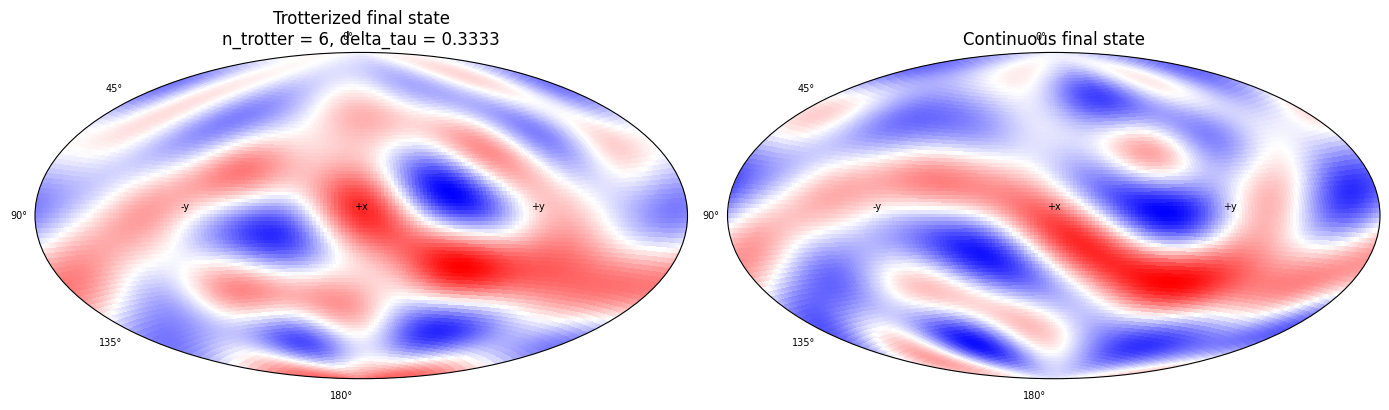

=== Section 8.3 ===
State fidelity between trotterized and continuous evolution = 0.866613


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': 'hammer'})


wigner_plot_hammer(
    psi_trotter_final,
    fig=fig,
    ax=axes[0],
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)
axes[0].set_title(
    f'Trotterized final state\n'
    f'n_trotter = {n_trotter}, delta_tau = {delta_tau:.4f}'
)

wigner_plot_hammer(
    psi_continuous_final,
    fig=fig,
    ax=axes[1],
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)
axes[1].set_title('Continuous final state')

plt.tight_layout()
plt.show()

print("=== Section 8.3 ===")
print(f"State fidelity between trotterized and continuous evolution = {comparison_fidelity:.6f}")


### 8.4 Compare Population Trajectories

Now compare the time evolution of the populations for the same basis states in the Trotterized and continuous evolutions. Both trajectories are sampled on the same time grid so the two panels can be read directly against each other.


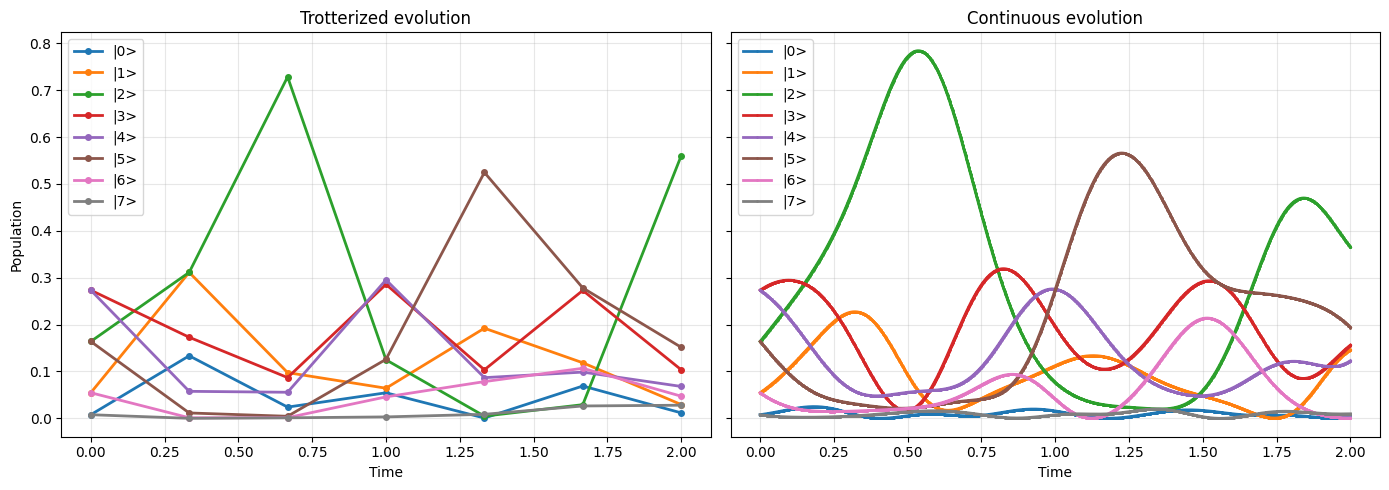

In [21]:
# Section 8.4: Population Evolution of Trotterized vs Continuous Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx in np.array(np.arange(8)):
    axes[0].plot(time_grid, trotter_populations[:, idx], 'o-', linewidth=2, markersize=4, label=f'|{idx}>')
    axes[1].plot(continuous_time_grid, continuous_populations[:, idx], 'o-', linewidth=2, markersize=1, label=f'|{idx}>')

axes[0].set_title('Trotterized evolution')
axes[1].set_title('Continuous evolution')

for ax in axes:
    ax.set_xlabel('Time')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Population')
plt.tight_layout()
plt.show()

### 8.5 Convergence as `delta_tau -> 0`

Repeat the Section 8.3 comparison for several Trotter step counts. As `delta_tau = T_total / n_trotter` gets smaller, the Trotterized evolution should approach the continuous result.


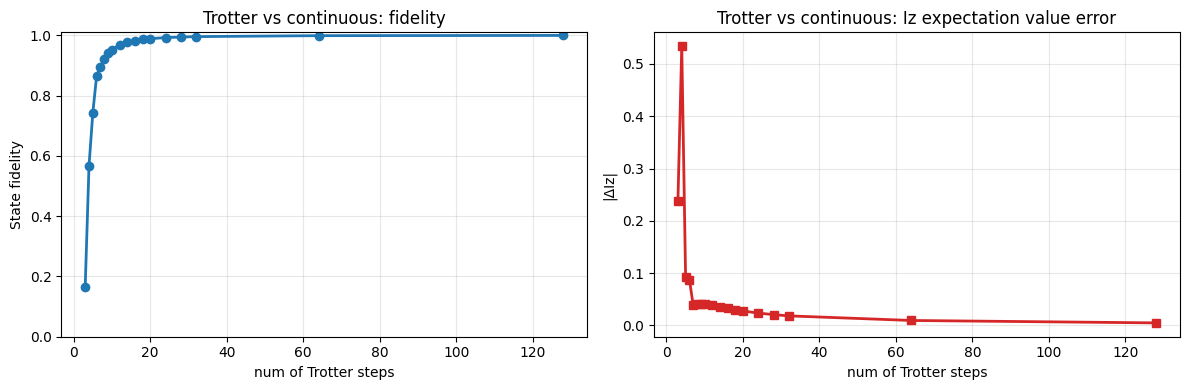

n_steps    delta_tau    fidelity    delta_Iz
      3     0.666667    0.164362       2.386454e-01
      4     0.500000    0.567784       5.341087e-01
      5     0.400000    0.743639       9.329048e-02
      6     0.333333    0.866613       8.754614e-02
      7     0.285714    0.894229       3.800604e-02
      8     0.250000    0.922126       4.086847e-02
      9     0.222222    0.940575       4.130756e-02
     10     0.200000    0.952950       4.096992e-02
     12     0.166667    0.968255       3.868087e-02
     14     0.142857    0.977077       3.563171e-02
     16     0.125000    0.982649       3.261402e-02
     18     0.111111    0.986400       2.987583e-02
     20     0.100000    0.989049       2.746394e-02
     24     0.083333    0.992456       2.352109e-02
     28     0.071429    0.994485       2.049727e-02
     32     0.062500    0.995793       1.813192e-02
     64     0.031250    0.998959       9.335767e-03
    128     0.015625    0.999741       4.715160e-03


In [22]:
# Section 8.5: Convergence with Many Different Trotter Step Sizes

trotter_step_list = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 24, 28, 32, 64, 128])
n_steps_array = np.zeros(len(trotter_step_list), dtype=int)
delta_tau_array = np.zeros(len(trotter_step_list), dtype=float)
fidelity_array = np.zeros(len(trotter_step_list), dtype=float)
delta_Iz_array = np.zeros(len(trotter_step_list), dtype=float)

# Get continuous final state expectation value for reference
Iz_continuous = qt.expect(Iz, psi_continuous_final)

for idx, n_steps in enumerate(trotter_step_list):
    delta_tau_local = T_total / n_steps
    U_step_local, _, _ = qkt.build_trotter_step(I, delta_tau_local, omega_y, Hz)
    psi_local_final = qkt.run_trotterized_evolution(psi0, U_step_local, n_steps)[-1]

    fidelity_local = qt.fidelity(psi_local_final, psi_continuous_final)
    Iz_local = qt.expect(Iz, psi_local_final)
    delta_Iz_local = np.abs(Iz_local - Iz_continuous)
    
    n_steps_array[idx] = n_steps
    delta_tau_array[idx] = delta_tau_local
    fidelity_array[idx] = fidelity_local
    delta_Iz_array[idx] = delta_Iz_local

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_steps_array, fidelity_array, 'o-', linewidth=2)
axes[0].set_xlabel('num of Trotter steps')
axes[0].set_ylabel('State fidelity')
axes[0].set_title('Trotter vs continuous: fidelity')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.01)

axes[1].plot(n_steps_array, delta_Iz_array, 's-', linewidth=2, color='tab:red')
axes[1].set_xlabel('num of Trotter steps')
axes[1].set_ylabel('|ΔIz|')
axes[1].set_title('Trotter vs continuous: Iz expectation value error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("n_steps    delta_tau    fidelity    delta_Iz")
for idx in range(len(trotter_step_list)):
    print(
        f"{n_steps_array[idx]:>7d}  {delta_tau_array[idx]:>11.6f}  "
        f"{fidelity_array[idx]:>10.6f}  {delta_Iz_array[idx]:>17.6e}"
    )


### 8.6 Sweep Total Evolution Time

Compare Trotterized vs continuous evolution across different total evolution times `T_total`, with fixed Trotter step count. This reveals how approximation errors scale with the evolution duration.


In [23]:
# Section 8.6: Sweep Both Total Evolution Time and Trotter Steps

# Sweep lists
T_total_list = np.array([0.5, 1.5, 2.5, 3.5, 4.5], dtype=float)
n_trotter_list = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 20, 24, 28, 32], dtype=int)

n_T_values = len(T_total_list)
n_n_values = len(n_trotter_list)

# Storage for results (rows: T_total, cols: n_trotter)
fidelity_matrix = np.zeros((n_T_values, n_n_values), dtype=float)
delta_Iz_matrix = np.zeros((n_T_values, n_n_values), dtype=float)

print("="*80)
print("Section 8.6: Comparing Convergence Across T_total and n_trotter")
print("="*80)
print(f"T_total values: {T_total_list}")
print(f"n_trotter values: {n_trotter_list}\n")

# Nested loop: sweep both T_total and n_trotter
for t_idx, T_total_val in enumerate(T_total_list):
    print(f"\nT_total = {T_total_val:.2f}:")
    
    for n_idx, n_trotter_val in enumerate(n_trotter_list):
        delta_tau_sweep = T_total_val / n_trotter_val
        
        # Build Trotter operators
        U_step_sweep, _, _ = qkt.build_trotter_step(I, delta_tau_sweep, omega_y, Hz)
        
        # Run Trotterized evolution
        psi_trotter_sweep = qkt.run_trotterized_evolution(psi0, U_step_sweep, n_trotter_val)[-1]
        
        # Run continuous evolution
        continuous_series_sweep = qkt.run_continuous_evolution(psi0, H_total, I, T_total_val, n_trotter_val)
        psi_continuous_sweep = continuous_series_sweep.states[-1]
        
        # Calculate metrics
        fidelity_sweep = qt.fidelity(psi_trotter_sweep, psi_continuous_sweep)
        Iz_continuous_sweep = qt.expect(Iz, psi_continuous_sweep)
        Iz_trotter_sweep = qt.expect(Iz, psi_trotter_sweep)
        delta_Iz_sweep = np.abs(Iz_trotter_sweep - Iz_continuous_sweep)
        
        # Store results
        fidelity_matrix[t_idx, n_idx] = fidelity_sweep
        delta_Iz_matrix[t_idx, n_idx] = delta_Iz_sweep
        
        print(f"  n_trotter = {n_trotter_val:2d}: fidelity = {fidelity_sweep:.6f}, Δ⟨Iz⟩ = {delta_Iz_sweep:.6e}")

print("="*80)


Section 8.6: Comparing Convergence Across T_total and n_trotter
T_total values: [0.5 1.5 2.5 3.5 4.5]
n_trotter values: [ 3  4  5  6  7  8  9 10 12 14 16 20 24 28 32]


T_total = 0.50:
  n_trotter =  3: fidelity = 0.948020, Δ⟨Iz⟩ = 3.132072e-01
  n_trotter =  4: fidelity = 0.971032, Δ⟨Iz⟩ = 2.359760e-01
  n_trotter =  5: fidelity = 0.981563, Δ⟨Iz⟩ = 1.896579e-01
  n_trotter =  6: fidelity = 0.987242, Δ⟨Iz⟩ = 1.586626e-01
  n_trotter =  7: fidelity = 0.990649, Δ⟨Iz⟩ = 1.364257e-01
  n_trotter =  8: fidelity = 0.992853, Δ⟨Iz⟩ = 1.196793e-01
  n_trotter =  9: fidelity = 0.994360, Δ⟨Iz⟩ = 1.066069e-01
  n_trotter = 10: fidelity = 0.995436, Δ⟨Iz⟩ = 9.611585e-02
  n_trotter = 12: fidelity = 0.996835, Δ⟨Iz⟩ = 8.031879e-02
  n_trotter = 14: fidelity = 0.997677, Δ⟨Iz⟩ = 6.898713e-02
  n_trotter = 16: fidelity = 0.998223, Δ⟨Iz⟩ = 6.046024e-02
  n_trotter = 20: fidelity = 0.998864, Δ⟨Iz⟩ = 4.847973e-02
  n_trotter = 24: fidelity = 0.999211, Δ⟨Iz⟩ = 4.046358e-02
  n_trotter = 28: fidelity = 0.9994

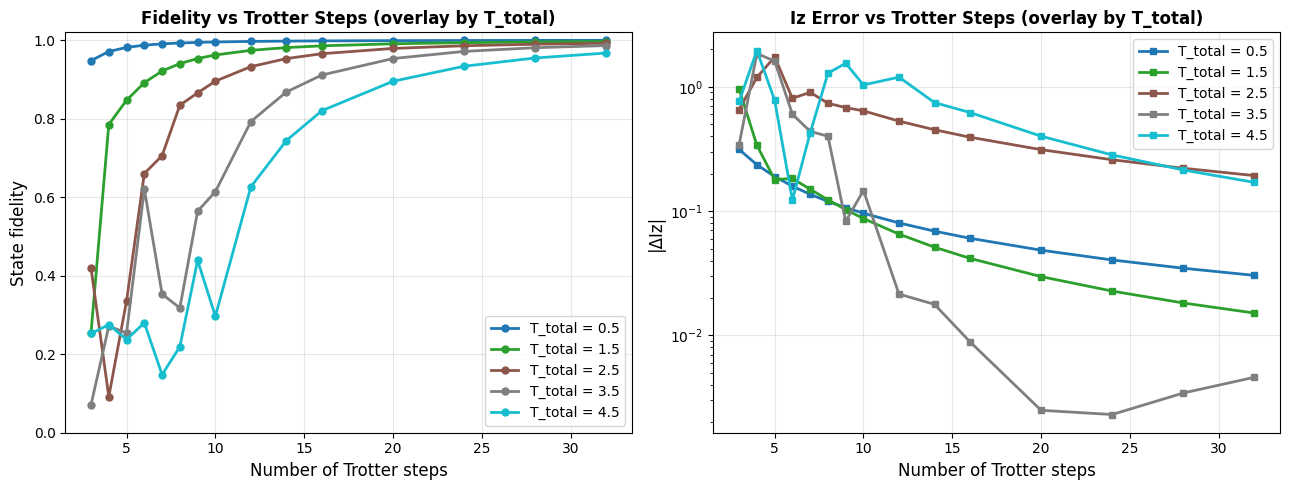


✓ Section 8.6 convergence analysis completed
  T_total values tested: 5
  n_trotter values tested: 15
  Fidelity range: [0.071384, 0.999557]
  Iz error range: [2.309784e-03, 1.957936e+00]


In [24]:
# Section 8.6: Plot Fidelity and Iz Error vs n_trotter (overlay by T_total)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Colors for each T_total value
colors = plt.cm.tab10(np.linspace(0, 1, n_T_values))

# Plot each T_total as a separate curve
for t_idx, T_total_val in enumerate(T_total_list):
    label = f'T_total = {T_total_val:.1f}'
    
    # Left plot: Fidelity vs n_trotter
    axes[0].plot(n_trotter_list, fidelity_matrix[t_idx, :], 'o-', 
                linewidth=2, markersize=5, color=colors[t_idx], label=label)
    
    # Right plot: Iz error vs n_trotter
    axes[1].plot(n_trotter_list, delta_Iz_matrix[t_idx, :], 's-', 
                linewidth=2, markersize=5, color=colors[t_idx], label=label)

# Left plot: Fidelity
axes[0].set_xlabel('Number of Trotter steps', fontsize=12)
axes[0].set_ylabel('State fidelity', fontsize=12)
axes[0].set_title('Fidelity vs Trotter Steps (overlay by T_total)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10, loc='best')
axes[0].set_ylim([0, 1.02])

# Right plot: Iz error
axes[1].set_xlabel('Number of Trotter steps', fontsize=12)
axes[1].set_ylabel('|ΔIz|', fontsize=12)
axes[1].set_title('Iz Error vs Trotter Steps (overlay by T_total)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10, loc='best')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n✓ Section 8.6 convergence analysis completed")
print(f"  T_total values tested: {len(T_total_list)}")
print(f"  n_trotter values tested: {len(n_trotter_list)}")
print(f"  Fidelity range: [{np.min(fidelity_matrix):.6f}, {np.max(fidelity_matrix):.6f}]")
print(f"  Iz error range: [{np.min(delta_Iz_matrix):.6e}, {np.max(delta_Iz_matrix):.6e}]")

# Section 9: OTOC Protocol from Blocher et al. (Phys. Rev. A 106, 042429)

This section reorganizes `OriginalCode/OTOC_simulation.ipynb` into the same `psyduck` workflow used above. The example follows the measurement protocol introduced in Blocher et al., *Measuring out-of-time-ordered correlation functions without reversing time evolution*, Phys. Rev. A **106**, 042429 (2022), DOI: `10.1103/PhysRevA.106.042429`.

The workflow used here is:
1. prepare the spin-coherent-state projector `V`
2. evolve the state under the driven higher-order spin Hamiltonian
3. rotate into the `H'` basis associated with the same angles `(theta, phi)`
4. reconstruct `F(t) = |<W_eps(t)>|^2` from the rotated-basis populations
5. report the OTOC growth signal `C(t) = 1 - F(t)`

Single-use lines stay inline in the notebook. Reusable OTOC post-processing lives in `ChaosQKT_functions.py`.


In [25]:
# Section 9.1: Setup the OTOC protocol

otoc_spin = 3.5
otoc_nucleus = Spin(I=otoc_spin)
otoc_Ix, otoc_Iy, otoc_Iz = otoc_nucleus.get_spin_operators()

otoc_gamma = 2 * np.pi * 200
otoc_order = 2
otoc_rabi = 2 * np.pi * 1 / (2 * (1888409 / 1e9))

otoc_Hzz = Hz_order(otoc_gamma, otoc_order, otoc_spin)
otoc_Hy = -otoc_rabi * otoc_Iy
otoc_H = otoc_Hy + otoc_Hzz

otoc_theta = np.pi / 2
otoc_phi = 0.0
otoc_eps = np.pi / 2

otoc_nucleus.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
otoc_psi0 = otoc_nucleus.state.copy()
otoc_rho0 = otoc_psi0 * otoc_psi0.dag()

# Create otoc_V
otoc_V_nucleus = Spin(I=otoc_spin)
otoc_V_nucleus.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
otoc_V_psi = otoc_V_nucleus.state
otoc_V = otoc_V_psi * otoc_V_psi.dag()

otoc_rotation = global_rotation(otoc_spin, otoc_phi, 'z') * global_rotation(otoc_spin, otoc_theta, 'y')
otoc_W_eps = otoc_rotation * (-1j * otoc_eps * otoc_Iz).expm() * otoc_rotation.dag()  # W_eps written in the lab basis

print("=== Section 9.1 ===")
print(f"Spin(I={otoc_spin}) with dimension {otoc_nucleus.dim}")
print(f"OTOC angles: theta = {otoc_theta:.3f}, phi = {otoc_phi:.3f}")
print(f"epsilon = {otoc_eps:.3f}")
print(f"||[V, W_eps]|| at t = 0 = {qt.commutator(otoc_V, otoc_W_eps).norm():.6e}")


=== Section 9.1 ===
Spin(I=3.5) with dimension 8
OTOC angles: theta = 1.571, phi = 0.000
epsilon = 1.571
||[V, W_eps]|| at t = 0 = 1.528239e-15


### 9.2 Continuous evolution and OTOC reconstruction

First compute a continuous reference trajectory with `Spin.evolve()`. Then reconstruct the paper's Loschmidt-echo-style quantity `F(t)` and the growth signal `C(t) = 1 - F(t)` from the populations in the rotated `H'` basis.


In [26]:
# Section 9.2: Continuous OTOC trajectory

otoc_t_max = 3e-3
otoc_t_step = 30e-6
otoc_time = np.arange(0, otoc_t_max + 0.5 * otoc_t_step, otoc_t_step)

otoc_continuous_nucleus = Spin(I=otoc_spin)
otoc_continuous_nucleus.state = otoc_psi0.copy()
otoc_continuous_series = otoc_continuous_nucleus.evolve(otoc_H, otoc_time)

otoc_C_cont, otoc_F_cont, otoc_probs_cont, otoc_m_vals = qkt.otoc_trajectory(
    otoc_continuous_series.states,
    theta=otoc_theta,
    phi=otoc_phi,
    eps=otoc_eps,
    j=otoc_spin
)

print("=== Section 9.2 ===")
print(f"Continuous trajectory length: {len(otoc_time)} time points")
print(f"Initial OTOC growth C(0) = {otoc_C_cont[0]:.6f}")
print(f"Final OTOC growth C(t_max) = {otoc_C_cont[-1]:.6f}")


=== Section 9.2 ===
Continuous trajectory length: 101 time points
Initial OTOC growth C(0) = -0.000000
Final OTOC growth C(t_max) = 0.835613


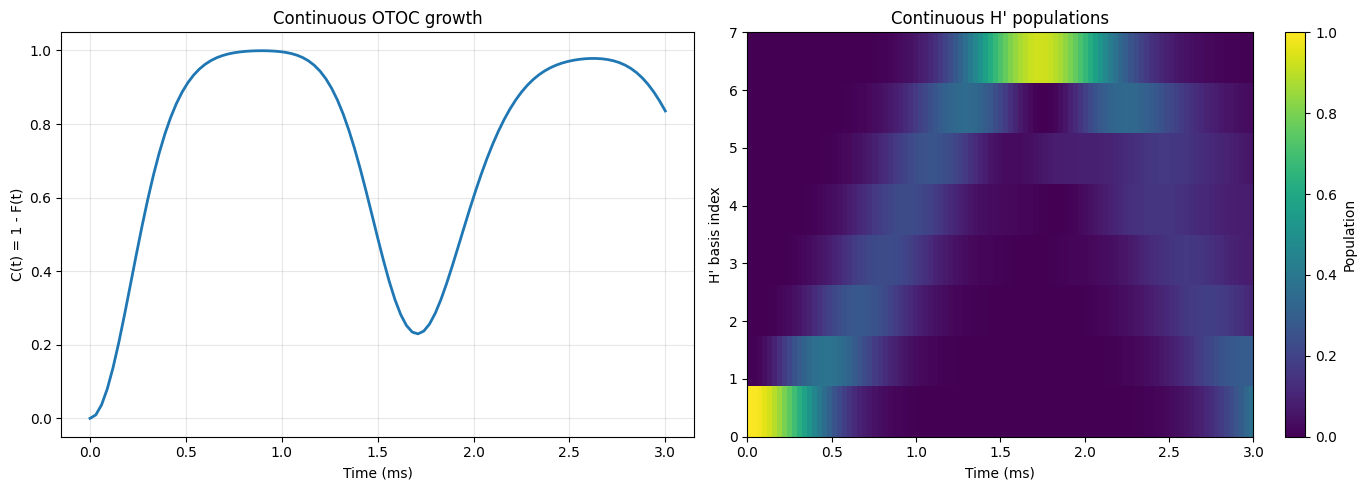

In [27]:
# Section 9.3: Plot the continuous OTOC and the H' basis populations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(otoc_time * 1e3, otoc_C_cont, linewidth=2)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title('Continuous OTOC growth')
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(
    otoc_probs_cont.T,
    aspect='auto',
    origin='lower',
    extent=[otoc_time[0] * 1e3, otoc_time[-1] * 1e3, 0, otoc_nucleus.dim - 1],
    cmap='viridis'
)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel("H' basis index")
axes[1].set_title("Continuous H' populations")
plt.colorbar(im, ax=axes[1], label='Population')

plt.tight_layout()
plt.show()


### 9.4 Compare the continuous and Trotterized OTOC traces

Now use the same total evolution time, but replace the continuous propagator with a first-order Trotter step. This isolates the digital approximation error at the level of the OTOC itself.


In [28]:
# Section 9.4: Trotterized OTOC on the same time grid

otoc_n_trotter = len(otoc_time) - 1
otoc_delta_t = otoc_time[-1] / otoc_n_trotter

otoc_U_step, otoc_Uy_step, otoc_Uzz_step = qkt.build_trotter_step(
    otoc_spin,
    otoc_delta_t,
    otoc_rabi,
    otoc_Hzz
)

otoc_trotter_states = qkt.run_trotterized_evolution(otoc_psi0, otoc_U_step, otoc_n_trotter)
otoc_C_trotter, otoc_F_trotter, otoc_probs_trotter, _ = qkt.otoc_trajectory(
    otoc_trotter_states,
    theta=otoc_theta,
    phi=otoc_phi,
    eps=otoc_eps,
    j=otoc_spin
)

print("=== Section 9.4 ===")
print(f"Trotter steps: {otoc_n_trotter}")
print(f"delta_t = {otoc_delta_t * 1e6:.2f} us")
print(f"Final |C_trotter - C_cont| = {abs(otoc_C_trotter[-1] - otoc_C_cont[-1]):.6e}")


=== Section 9.4 ===
Trotter steps: 100
delta_t = 30.00 us
Final |C_trotter - C_cont| = 1.730004e-04


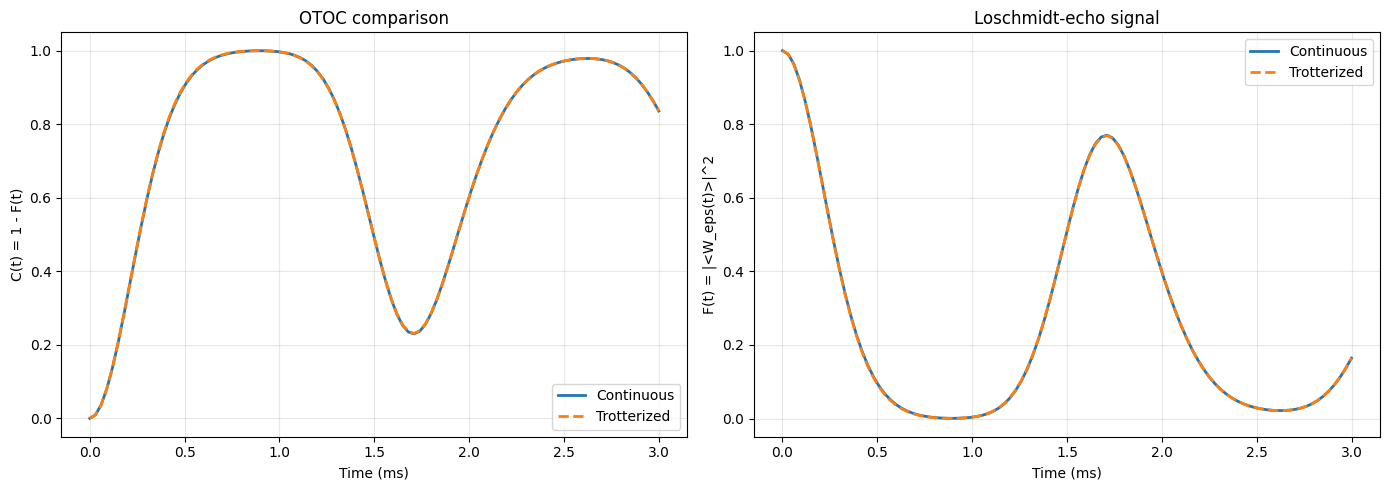

In [29]:
# Section 9.4: Plot continuous and Trotterized OTOC together

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].plot(otoc_time * 1e3, otoc_C_cont, linewidth=2, label='Continuous')
axes[0].plot(otoc_time * 1e3, otoc_C_trotter, '--', linewidth=2, label='Trotterized')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title('OTOC comparison')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(otoc_time * 1e3, otoc_F_cont, linewidth=2, label='Continuous')
axes[1].plot(otoc_time * 1e3, otoc_F_trotter, '--', linewidth=2, label='Trotterized')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('F(t) = |<W_eps(t)>|^2')
axes[1].set_title('Loschmidt-echo signal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 9.5 Sweep the Trotter number

This reproduces the last part of the original notebook: fix the total evolution time, vary the Trotter number `N`, and track how both the full OTOC trace and the final-time value converge.


In [30]:
# Section 9.5: Sweep Trotter number at fixed total time

otoc_trotter_numbers = np.arange(1, 21)
otoc_C_traces = {}
otoc_C_final = []

for n_steps in otoc_trotter_numbers:
    dt_local = otoc_time[-1] / n_steps
    U_step_local, _, _ = qkt.build_trotter_step(otoc_spin, dt_local, otoc_rabi, otoc_Hzz)
    trotter_states_local = qkt.run_trotterized_evolution(otoc_psi0, U_step_local, int(n_steps))
    C_local, _, _, _ = qkt.otoc_trajectory(
        trotter_states_local,
        theta=otoc_theta,
        phi=otoc_phi,
        eps=otoc_eps,
        j=otoc_spin
    )
    otoc_C_traces[int(n_steps)] = C_local
    otoc_C_final.append(C_local[-1])


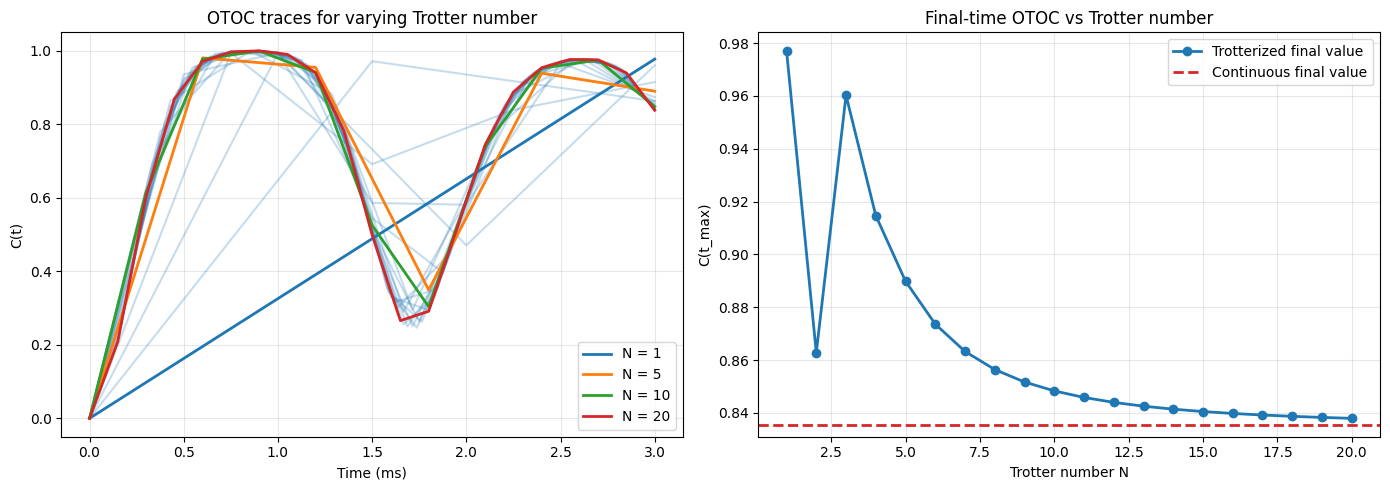

In [31]:
# Section 9.5: Plot the Trotter sweep

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_steps, C_trace in otoc_C_traces.items():
    t_axis = np.linspace(0, otoc_time[-1] * 1e3, len(C_trace))
    axes[0].plot(t_axis, C_trace, alpha=0.25, color='tab:blue')

for n_steps in [1, 5, 10, 20]:
    if n_steps in otoc_C_traces:
        t_axis = np.linspace(0, otoc_time[-1] * 1e3, len(otoc_C_traces[n_steps]))
        axes[0].plot(t_axis, otoc_C_traces[n_steps], linewidth=2, label=f'N = {n_steps}')

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t)')
axes[0].set_title('OTOC traces for varying Trotter number')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(otoc_trotter_numbers, otoc_C_final, 'o-', linewidth=2, label='Trotterized final value')
axes[1].axhline(otoc_C_cont[-1], color='tab:red', linestyle='--', linewidth=2, label='Continuous final value')
axes[1].set_xlabel('Trotter number N')
axes[1].set_ylabel('C(t_max)')
axes[1].set_title('Final-time OTOC vs Trotter number')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Section 9 Notes

The OTOC here is reconstructed from rotated-basis populations rather than from explicit time reversal. In this notebook, the continuous and Trotterized trajectories use the same population-based post-processing, so any mismatch comes from the propagation model rather than from the measurement rule itself.


## Quick Reference

### Available Functions

#### From psyduck:
- `Spin(I=7/2)` - Create spin systems and prepare coherent states
  - `.make_displaced_coherent_state(theta, phi)` - Prepare a spin-coherent state
  - `.get_spin_operators()` - Get `(Ix, Iy, Iz)`
  - `.expectation(operator)` - Calculate expectation values
  - `.evolve(H, times)` - Continuous time evolution under a Hamiltonian
  - `.linear_entropy()` - Calculate linear entropy
  - `.state` - Current quantum state
- `psyduck.evolve.kicked_dynamics()` - Quantum kicked-top simulator
- `psyduck.operations.global_rotation()` - Build full-spin rotation operators
- `psyduck.plotting.wigner_plot_hammer()` - Hammer projection visualization

#### From ChaosQKT_functions:
- `Hz_order(kappa, order, spin_I)` - Build the higher-order `I_z^order` Hamiltonian
- `build_trotter_step(...)`, `run_trotterized_evolution(...)` - Trotterized propagators for Sections 8-9
- `run_continuous_evolution(...)` - Continuous reference trajectory helper
- `probs_in_Hprime_basis(state, theta, phi, j)` - Populations in the tilted measurement basis
- `otoc_from_populations(m_vals, probs, eps)` - Convert populations into the OTOC signal
- `otoc_trajectory(states, theta, phi, eps, j)` - Compute `C_n`, `F_n`, and rotated-basis populations
- `normalize_data()`, `smooth_data()`, `downsample_data()` - Data processing utilities

### Key Points
- Sections 3-7 use `psyduck` for coherent-state preparation, kicked dynamics, and visualization.
- Section 8 compares Trotterized evolution against `Spin.evolve()` under the same Hamiltonian.
- Section 9 reorganizes the OTOC notebook into the same `psyduck` workflow and reconstructs the OTOC from rotated-basis populations.
- `ChaosQKT_functions.py` now carries the reusable higher-order, Trotter, and OTOC helpers used in Sections 8-9.
